# 4 — Penerapan di lokasi nyata: apa yang bertahan, apa yang runtuh

Notebook 1–3 dikerjakan di **Wildtrack**: lapangan terbuka, orang berjalan, tujuh
kamera terkalibrasi, dan ground truth lengkap. Notebook ini memindahkan sistem itu
ke **pantry kantor** — dua kamera, orang duduk, tidak ada kalibrasi, tidak ada
ground truth.

Yang menarik bukan "berhasil atau tidak", tapi **mana kesimpulan yang bertahan dan
mana yang ternyata cuma berlaku di Wildtrack.**

## Persiapan

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

APP = Path.cwd().parent / 'crowdflow_app'
assert APP.exists(), 'jalankan dari folder crowdflow_inti'
plt.rcParams['figure.dpi'] = 110
print('siap')

siap


## 1. Yang pertama runtuh: ambang conf

Notebook 1 memilih conf 0,25 lewat sapuan di Wildtrack. Pertanyaannya: apakah
pilihan itu masih benar di pantry?

Untuk menjawabnya perlu ground truth, dan pantry tidak punya. Jadi dibuat: **106
orang ditandai manusia di 10 frame**, menyebar dari jam sepi sampai puncak makan
siang, di kedua kamera.

In [2]:
gt = json.load(open(APP / 'reid/gt_orang_pantry.json'))
ringkas = pd.DataFrame([{'kamera': f"C{f['cam']}", 'jam': f['jam'], 'orang': len(f['orang'])}
                        for f in gt['frame']])
print(f"total {ringkas['orang'].sum()} orang dianotasi di {len(ringkas)} frame")
ringkas.pivot(index='jam', columns='kamera', values='orang')

total 106 orang dianotasi di 10 frame


kamera,C1,C2
jam,,
11:40,9,9
12:10,19,23
13:10,7,6
13:40,4,5
15:10,12,12


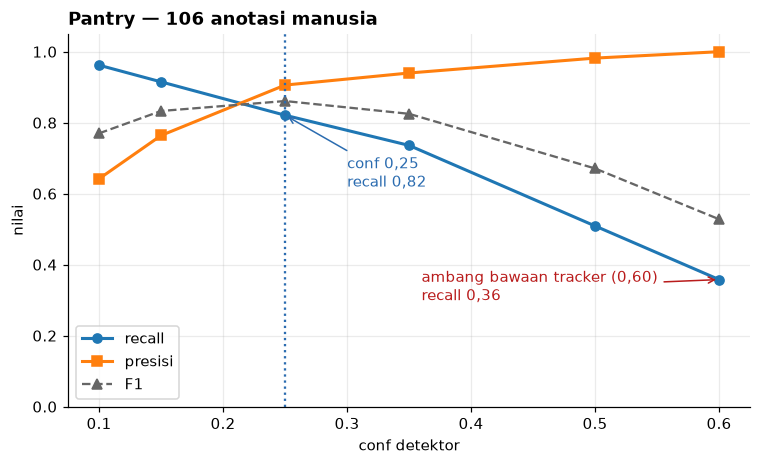

,conf,presisi,recall,F1,TP,FP,FN
0,0.10,0.642,0.962,0.770,102.0,57.0,4.0
1,0.15,0.764,0.915,0.833,97.0,30.0,9.0
2,0.25,0.906,0.821,0.861,87.0,9.0,19.0
3,0.35,0.940,0.736,0.825,78.0,5.0,28.0
4,0.50,0.982,0.509,0.671,54.0,1.0,52.0
5,0.60,1.000,0.358,0.528,38.0,0.0,68.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
sc = pd.read_csv(APP / 'reid/hasil_sapu_conf_pantry.csv')
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(sc['conf'], sc['recall'], 'o-', lw=2, label='recall')
ax.plot(sc['conf'], sc['presisi'], 's-', lw=2, label='presisi')
ax.plot(sc['conf'], sc['F1'], '^--', lw=1.5, color='#666', label='F1')
ax.axvline(0.25, color='#2b6cb0', ls=':', lw=1.5)
ax.annotate('conf 0,25\nrecall 0,82', (0.25, 0.821), xytext=(0.30, 0.62),
            arrowprops=dict(arrowstyle='->', color='#2b6cb0'), color='#2b6cb0')
ax.annotate('ambang bawaan tracker (0,60)\nrecall 0,36', (0.60, 0.358), xytext=(0.36, 0.30),
            arrowprops=dict(arrowstyle='->', color='#b91c1c'), color='#b91c1c')
ax.set_xlabel('conf detektor'); ax.set_ylabel('nilai')
ax.set_title('Pantry — 106 anotasi manusia', loc='left', weight='bold')
ax.grid(alpha=.25); ax.legend(); ax.set_ylim(0, 1.05)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.show()
sc

**conf 0,25 bertahan** — F1 tertinggi (0,861), sama seperti kesimpulan Wildtrack.

Tapi ada yang jauh lebih penting di grafik itu, dan tidak ada hubungannya dengan conf.

Nilai bawaan BoTSORT untuk melahirkan ID baru adalah **0,60**. Di ambang itu recall
cuma **0,358** — artinya **dua pertiga pengunjung tidak akan pernah mendapat ID**,
apa pun yang dilakukan tracker sesudahnya. Bukan hilang sesekali; secara struktural
tidak boleh lahir.

Penyebabnya khas pantry: orang duduk, setengah tertutup meja. Skornya rendah bukan
karena detektor ragu itu orang, tapi karena yang terlihat cuma sepotong.

## 2. Detektor menyaring, lalu tracker menyaring lagi

Ini yang tidak terlihat di notebook 1 dan 2, karena keduanya ditulis di berkas
terpisah: **detektor dan tracker punya ambang sendiri-sendiri.**

Menyetel conf detektor ke 0,25 tidak ada gunanya kalau tracker membuang lagi
semua yang di bawah 0,60.

In [4]:
pd.DataFrame([
    {'tahap': 'deteksi (conf 0,25)',        'kotak per frame': 15.9},
    {'tahap': 'track, ambang bawaan 0,5/0,6', 'kotak per frame': 9.6},
    {'tahap': 'track, ambang diselaraskan 0,25', 'kotak per frame': 15.5},
]).set_index('tahap')

,kotak per frame
tahap,
"deteksi (conf 0,25)",15.9
"track, ambang bawaan 0,5/0,6",9.6
"track, ambang diselaraskan 0,25",15.5


Diukur di 120 frame pantry pada jam puncak. Ambang bawaan membuang **40%**
deteksi — dan yang dibuang justru orang duduk yang setengah tertutup, persis yang
mau ditangkap dengan menurunkan conf.

**Pelajaran yang berlaku umum:** ambang detektor dan ambang tracker adalah satu
paket. Menyetel salah satunya sendirian bisa tidak berpengaruh sama sekali.

## 3. Titik balik: kesimpulan Re-ID dari notebook 3 TIDAK berlaku di sini

Notebook 3 menemukan CLIP-ReID punya mAP tertinggi tapi IDF1 terendah. Di pantry,
pertanyaannya berbeda: **apakah embedding-nya masih bisa membedakan orang sama
dari orang berbeda?**

Diukur dengan protokol yang sama pada crop pantry: kemiripan cosine antar crop
orang yang sama, versus antar orang yang berbeda.

In [5]:
daya = pd.DataFrame([
    {'model': 'CLIP-ReID',                'orang sama': 0.952, 'orang beda': 0.919},
    {'model': 'osnet_ain_x1_0_wildtrack', 'orang sama': 0.662, 'orang beda': 0.465},
])
daya['selisih'] = (daya['orang sama'] - daya['orang beda']).round(3)
daya.set_index('model')

,orang sama,orang beda,selisih
model,,,
CLIP-ReID,0.952,0.919,0.033
osnet_ain_x1_0_wildtrack,0.662,0.465,0.197


**Selisih 0,033 versus 0,197 — enam kali lipat.**

Ini bukan soal mana yang lebih pintar. Tracker mengambil keputusan **ya/tidak
dengan garis batas**: "apakah kemiripan ini di atas ambang?". CLIP-ReID memberi
skor yang benar urutannya, tapi semuanya berdempetan di 0,92–0,95 — tidak ada
garis batas yang memisahkan.

**mAP menilai urutan; tracker butuh garis batas.** Itu penjelasan mekanis untuk
pembalikan yang ditemukan notebook 3.

Catatan jujur: pada percobaan pertama saya menyimpulkan "Re-ID tidak berguna di
pantry" — padahal yang diuji baru CLIP-ReID. Kesimpulan tentang **satu model**
dipakai untuk menghakimi **satu domain**. Setelah diuji dengan model lain,
kesimpulannya berubah.

## 4. Fine-tune di domain sendiri: tidak terbukti

Kalau modelnya lemah di pantry, latih saja dengan data pantry. Dataset dibangun
dari track: tiap track panjang dianggap satu identitas, crop-nya dipanen otomatis,
lalu **disisir manusia** — 44 identitas dari 98 hasil panen.

OSNet-AIN di-fine-tune dari bobot Wildtrack, lalu diuji ulang di Wildtrack (satu-
satunya tempat yang punya ground truth identitas).

In [6]:
d = pd.read_csv(APP / 'reid/hasil_idf1_pantry_finetune.csv')
p = d.pivot_table(index='cam', columns='model', values='IDF1')
delta = (p['osnet_ain_x1_0_pantry'] - p['osnet_ain_x1_0_wildtrack']).round(2)
print(f"rata-rata selisih : {delta.mean():+.2f}")
print(f"simpangan baku    : {delta.std():.2f}")
print(f"menang di         : {(delta > 0).sum()} dari {len(delta)} kamera")
delta.to_frame('pantry - wildtrack')

rata-rata selisih : +0.43
simpangan baku    : 2.98
menang di         : 2 dari 7 kamera


,pantry - wildtrack
cam,
C1,-2.74
C2,-0.80
C3,5.14
C4,-0.46
C5,-0.14
C6,3.99
C7,-1.98


Rata-ratanya **+0,43** — terlihat seperti perbaikan kecil.

Tapi simpangan bakunya **2,98**, tujuh kali lebih besar dari rata-ratanya. Dan
kalau dilihat per kamera: **menang cuma di 2 dari 7**. Angka rata-rata positif
semata-mata karena dua kamera melonjak (+5,14 dan +3,99), sementara lima lainnya
turun.

Sempat muncul dugaan menarik: mungkin fine-tune menolong justru di kamera yang
paling sulit? Korelasi selisih dengan IDF1 awal memang −0,68. Tapi itu **regresi
ke rata-rata**, artefak statistik yang muncul otomatis pada pengukuran berderau.

In [7]:
from itertools import combinations
m = list(p.columns)
r = pd.DataFrame([{'pasangan': f"{a.replace('osnet_ain_x1_0_','')} - {b.replace('osnet_ain_x1_0_','')}",
                   'korelasi delta vs awal': round(float(np.corrcoef(p[b], p[a] - p[b])[0, 1]), 2)}
                  for a, b in combinations(m, 2)])
r.sort_values('korelasi delta vs awal').reset_index(drop=True)

,pasangan,korelasi delta vs awal
0,clipreid - wildtrack,-0.87
1,clipreid - osnet_x0_25_msmt17,-0.87
2,clipreid - msmt17,-0.85
3,clipreid - pantry,-0.78
4,pantry - wildtrack,-0.68
5,pantry - osnet_x0_25_msmt17,-0.68
6,msmt17 - osnet_x0_25_msmt17,-0.39
7,wildtrack - osnet_x0_25_msmt17,-0.34
8,msmt17 - wildtrack,-0.28
9,msmt17 - pantry,0.05


Pola "membaik di kamera terburuk" muncul di **hampir semua pasangan model**,
sekuat −0,87. Angka pantry (−0,68) berada di tengah, tidak istimewa. Jadi lonjakan
dua kamera itu artefak, bukan sinyal.

**Kesimpulan: tidak ada bukti fine-tune domain memperbaiki apa pun** — dengan 31
identitas latih.

## 5. Dan satu jebakan yang hampir lolos: mAP pada data pantry

Selama fine-tune, mAP pada test set pantry naik dari 92,3 ke 94,7. Kelihatan
berhasil.

Masalahnya angka **92,3 itu diukur SEBELUM training sama sekali.** Model yang
belum pernah melihat pantry langsung bisa mencocokkan crop-nya nyaris sempurna.

Sebabnya: orang duduk tidak berpindah, jadi setiap crop dari satu identitas punya
**kursi, meja, botol, dan tas yang sama**. Model bisa "mengenali orang" dengan
menghafal latar belakangnya.

**Di data seperti ini mAP tidak mengukur apa pun yang kita inginkan.** Satu-satunya
ukuran yang sah adalah IDF1 setelah dipasang ke tracker — dan itulah yang dipakai
di bagian 4.

## 6. Berapa selisih IDF1 yang sebenarnya bermakna?

Seluruh tabel perbandingan model di notebook 3 berselisih di bawah satu poin.
Pertanyaan yang belum pernah ditanyakan: **apakah selisih sekecil itu berarti?**

In [8]:
ring = (d.groupby('model')[['IDF1', 'IDSW', 'MOTA', 'FPS']]
          .agg({'IDF1': 'mean', 'IDSW': 'sum', 'MOTA': 'mean', 'FPS': 'mean'})
          .round(2).sort_values('IDF1', ascending=False))
mAP = pd.read_csv(APP / 'reid/hasil_perbandingan_reid.csv', index_col=0)['mAP']
ring['mAP'] = [mAP.get(i, np.nan) for i in ring.index]

sd = [float((p[a] - p[b]).std()) for a, b in combinations(p.columns, 2)]
galat = np.median(sd) / np.sqrt(len(p))
print(f"simpangan baku selisih antar-kamera : {np.median(sd):.2f}")
print(f"galat baku rata-rata {len(p)} kamera      : {galat:.2f}")
print(f"selisih di bawah ~{2*galat:.1f} poin       : TIDAK bermakna\n")
ring

simpangan baku selisih antar-kamera : 3.57
galat baku rata-rata 7 kamera      : 1.35
selisih di bawah ~2.7 poin       : TIDAK bermakna



,IDF1,IDSW,MOTA,FPS,mAP
model,,,,,
osnet_ain_x1_0_msmt17,47.37,1642,27.23,7.60,19.2
osnet_ain_x1_0_pantry,46.97,1796,27.07,10.14,NaN
osnet_ain_x1_0_wildtrack,46.54,1966,27.13,7.68,21.5
osnet_x0_25_msmt17,44.55,1753,25.98,11.72,9.1
clipreid,42.05,1819,23.71,2.90,49.0


**Empat model teratas tidak dapat diperingkat.** Selisih 47,37 sampai 44,55
semuanya di bawah batas derau 2,7 poin.

Yang benar-benar terpisah hanya **CLIP-ReID**, tertinggal 5,3 poin — dan justru
dialah yang mAP-nya dua kali lipat semua model lain.

Perhatikan kolom mAP dan IDF1 berdampingan: **urutannya hampir persis kebalikan.**
Model dengan mAP 9,1 mengungguli model dengan mAP 49,0.

Jadi klaim yang bisa dipertahankan bukan "model X terbaik", melainkan:

> Pilihan model Re-ID hampir tidak berpengaruh, kecuali CLIP-ReID yang jelas lebih
> buruk. Yang benar-benar menentukan adalah **cara memasangnya ke tracker**.

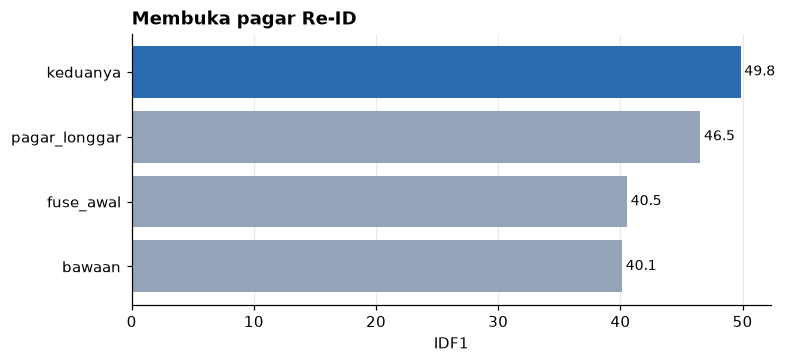

In [9]:
g = pd.read_csv(APP / 'reid/hasil_gerbang.csv')
b = g.groupby('konfig')['IDF1'].mean().round(2).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(b.index, b.values, color=['#94a3b8'] * (len(b) - 1) + ['#2b6cb0'])
for i, v in enumerate(b.values):
    ax.text(v + .3, i, f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('IDF1'); ax.set_title('Membuka pagar Re-ID', loc='left', weight='bold')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
ax.grid(axis='x', alpha=.25); ax.set_axisbelow(True)
plt.show()

Membuka `proximity_thresh`/`appearance_thresh` dari 0,5/0,25 ke 0,9/0,4:
**+10 poin IDF1**. Mengganti model dari terburuk ke terbaik: **+1 poin**.

Sepuluh kali lipat. Dan pagar adalah satu baris konfigurasi.

## 7. Lintas kamera: diukur, bukan diasumsikan

Tujuan terakhir: apakah orang yang sama bisa diberi ID sama di kamera 1 dan 2?

Pencocokan dilakukan dengan Hungarian pada embedding rata-rata tiap track, lalu
**dinilai terhadap anotasi manusia**.

In [10]:
pd.DataFrame([
    {'model Re-ID': 'osnet_ain_x1_0_wildtrack', 'benar': '1 dari 7', 'persen': 14},
    {'model Re-ID': 'osnet_ain_x1_0_pantry',    'benar': '1 dari 5', 'persen': 20},
    {'model Re-ID': 'tebakan acak',             'benar': '—',        'persen': 3},
]).set_index('model Re-ID')

,benar,persen
model Re-ID,,
osnet_ain_x1_0_wildtrack,1 dari 7,14
osnet_ain_x1_0_pantry,1 dari 5,20
tebakan acak,—,3


Ada sinyal — 14–20% jelas di atas 3%. Tapi **4 dari 5 salah**, jadi tidak
ada keputusan yang boleh dibangun di atasnya.

Dan ada batas yang lebih dalam: waktu potongan gambar tiap pasangan anotasi
disandingkan untuk diperiksa mata, **beberapa titik ternyata jatuh bukan pada
orang** — pada meja, kantong, layar. Acuannya sendiri tidak cukup andal.

Artinya angka 14–20% itu pun diukur dengan mistar yang bengkok. Yang bisa
disimpulkan dengan yakin: **pencocokan lintas kamera di pantry belum terselesaikan,
dan langkah pertama untuk mengejarnya bukan model yang lebih baik, melainkan acuan
yang benar.**

## 8. Kesimpulan

| | Wildtrack | pantry |
|---|---|---|
| conf 0,25 optimal | ✅ | ✅ **bertahan** |
| pagar dibuka jauh lebih penting dari pilihan model | ✅ | ✅ **bertahan** |
| mAP tidak memprediksi IDF1 | ✅ | ✅ **bertahan, lebih ekstrem** |
| ambang tracker aman dilonggarkan | ✅ | ⚠️ **tergantung presisi detektor** |
| model X terbaik | — | ❌ **di bawah batas derau** |
| fine-tune domain menolong | — | ❌ **tidak terbukti** |
| ID sama lintas kamera | ✅ (ada kalibrasi) | ❌ **20%** |

Tiga baris pertama adalah temuan yang berlaku lintas domain — dan ketiganya soal
**cara memasang**, bukan soal memilih model.

Tiga baris terakhir adalah batas yang ditemukan justru karena diukur. Yang paling
berharga dari ketiganya bukan kegagalannya, tapi bahwa masing-masing punya angka
dan protokol — bukan dugaan.

**Yang paling kokoh dari seluruh sistem justru bagian yang tidak butuh identitas
sama sekali:** jumlah orang per waktu dan peta kepadatan, keduanya hanya bergantung
pada detektor — satu-satunya komponen yang diuji langsung terhadap anotasi manusia.